In [4]:
from sklearn.datasets import make_regression
import pandas as pd

from sklearn.linear_model import Ridge
import matplotlib.pyplot as plt
import numpy as np 

In [ ]:
x,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1,noise=20,random_state=13)

In [5]:
Rid = Ridge()
Rid.fit(x,y)
print("Slope m" ,Rid.coef_)
print("intercept b" ,Rid.intercept_)

Slope m [27.51130507]
intercept b -2.276241917183367


In [7]:
Rid_10 = Ridge(alpha=10)
Rid_10.fit(x,y)
print("Slope m" ,Rid_10.coef_)
print("intercept b" ,Rid_10.intercept_)

Slope m [24.9546267]
intercept b -2.1269130035235735


In [6]:
Rid_100 = Ridge(alpha=100)
Rid_100.fit(x,y)
print("Slope m" ,Rid_100.coef_)
print("intercept b" ,Rid_100.intercept_)

Slope m [12.93442104]
intercept b -1.4248441496033308


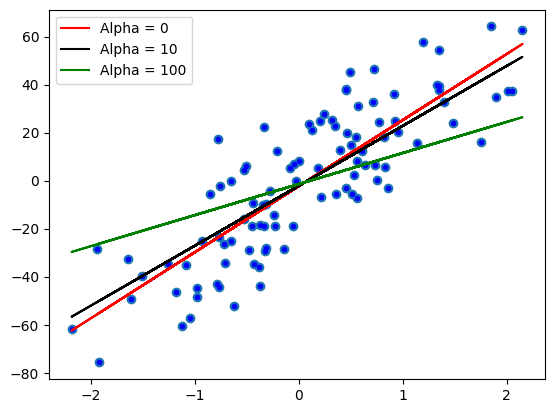

In [16]:
plt.scatter(x,y)
plt.plot(x,y ,"b.")
plt.plot(x,Rid.predict(x) , "Red" , label="Alpha = 0")
plt.plot(x,Rid_10.predict(x) , "Black" , label="Alpha = 10")
plt.plot(x,Rid_100.predict(x) , "Green" , label="Alpha = 100")
plt.legend()
plt.show()

# **Creating my own Ridge**

In [59]:
class My_Ridge:

    def __init__(self , alpha = 0.01):
        self.b = None
        self.m = None
        self.alpha = alpha

    def fit(self , x_train ,y_train):
        num = 0
        den = 0

        for i in range(x_train.shape[0]):

            num = num + (y_train[i] - y_train.mean()) * (x_train[i] - x_train.mean())
            den = den + (x_train[i] - x_train.mean()) * (x_train[i] - x_train.mean()) 

            self.m = num/ (den+ self.alpha)

        self.b = y_train.mean() - (self.m * x_train.mean())

        print(self.b) 
        print(self.m)


    def predict ( self,x_test):
        return (self.m*x_test) + self.b

In [60]:
My = My_Ridge(alpha=100)
My.fit(x,y)


[-1.42484415]
[12.93442104]
